<a href="https://colab.research.google.com/github/jerry-phillips/Capstone-Survey-Existing-Research/blob/main/%20KMeans_Model_UMass_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Section 1: Data Loading & Exploration

In [ ]:
# imports
from google.colab import files
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# pick the file from computer
uploaded = files.upload()

Saving video_game_reviews.csv to video_game_reviews (1).csv


In [ ]:
# create dataframe
df = pd.read_csv('video_game_reviews.csv')
df.head()

,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
0,Grand Theft Auto V,36.4,All Ages,41.41,PC,No,Game Freak,Innersloth,2015,Adventure,No,55.3,Medium,Average,Poor,"Solid game, but too many bugs.",Offline,1
1,The Sims 4,38.3,Adults,57.56,PC,No,Nintendo,Electronic Arts,2015,Shooter,Yes,34.6,Low,Poor,Poor,"Solid game, but too many bugs.",Offline,3
2,Minecraft,26.8,Teens,44.93,PC,Yes,Bungie,Capcom,2012,Adventure,Yes,13.9,Low,Good,Average,"Great game, but the graphics could be better.",Offline,5
3,Bioshock Infinite,38.4,All Ages,48.29,Mobile,Yes,Game Freak,Nintendo,2015,Sports,No,41.9,Medium,Good,Excellent,"Solid game, but the graphics could be better.",Online,4
4,Half-Life: Alyx,30.1,Adults,55.49,PlayStation,Yes,Game Freak,Epic Games,2022,RPG,Yes,13.2,High,Poor,Good,"Great game, but too many bugs.",Offline,1


In [ ]:
# See the shape and first few rows
print(df.shape)

(47774, 18)


In [ ]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47774 entries, 0 to 47773
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Game Title               47774 non-null  object 
 1   User Rating              47774 non-null  float64
 2   Age Group Targeted       47774 non-null  object 
 3   Price                    47774 non-null  float64
 4   Platform                 47774 non-null  object 
 5   Requires Special Device  47774 non-null  object 
 6   Developer                47774 non-null  object 
 7   Publisher                47774 non-null  object 
 8   Release Year             47774 non-null  int64  
 9   Genre                    47774 non-null  object 
 10  Multiplayer              47774 non-null  object 
 11  Game Length (Hours)      47774 non-null  float64
 12  Graphics Quality         47774 non-null  object 
 13  Soundtrack Quality       47774 non-null  object 
 14  Story Quality         

In [ ]:
# Check unique values for key categorical columns
for col in ['Genre', 'Platform', 'Age Group Targeted', 'Graphics Quality',
            'Soundtrack Quality', 'Story Quality', 'Multiplayer', 'Game Mode']:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()}")
    print()

Genre: 10 unique values -> ['Adventure' 'Shooter' 'Sports' 'RPG' 'Simulation' 'Strategy' 'Fighting'
 'Action' 'Party' 'Puzzle']

Platform: 5 unique values -> ['PC' 'Mobile' 'PlayStation' 'Xbox' 'Nintendo Switch']

Age Group Targeted: 4 unique values -> ['All Ages' 'Adults' 'Teens' 'Kids']

Graphics Quality: 4 unique values -> ['Medium' 'Low' 'High' 'Ultra']

Soundtrack Quality: 4 unique values -> ['Average' 'Poor' 'Good' 'Excellent']

Story Quality: 4 unique values -> ['Poor' 'Average' 'Excellent' 'Good']

Multiplayer: 2 unique values -> ['No' 'Yes']

Game Mode: 2 unique values -> ['Offline' 'Online']



## Section 2: Data Preprocessing & Feature Engineering


In [ ]:
# Make a copy to work with
df_model = df.copy()

# --- Ordinal Encoding ---
graphics_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Ultra': 3}
soundtrack_order = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
story_order = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
age_order = {'Kids': 0, 'Teens': 1, 'All Ages': 2, 'Adults': 3}

df_model['Graphics Quality'] = df_model['Graphics Quality'].map(graphics_order)
df_model['Soundtrack Quality'] = df_model['Soundtrack Quality'].map(soundtrack_order)
df_model['Story Quality'] = df_model['Story Quality'].map(story_order)
df_model['Age Group Targeted'] = df_model['Age Group Targeted'].map(age_order)

# --- Binary Encoding ---
df_model['Multiplayer'] = df_model['Multiplayer'].map({'No': 0, 'Yes': 1})
df_model['Game Mode'] = df_model['Game Mode'].map({'Offline': 0, 'Online': 1})

# --- One-Hot Encoding ---
df_model = pd.get_dummies(df_model, columns=['Genre', 'Platform'], drop_first=False)

# --- Select features (drop non-feature columns) ---
drop_cols = ['Game Title', 'Developer', 'Publisher', 'User Review Text', 'Requires Special Device']
df_features = df_model.drop(columns=drop_cols)

# --- Scale everything ---
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)

print(f"Final feature set shape: {df_scaled.shape}")
df_scaled.head()

Final feature set shape: (47774, 26)


,User Rating,Age Group Targeted,Price,Release Year,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,Game Mode,...,Genre_RPG,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy,Platform_Mobile,Platform_Nintendo Switch,Platform_PC,Platform_PlayStation,Platform_Xbox
0,0.884851,0.455667,0.126615,-0.367734,-0.991537,1.437616,-0.449934,-0.454514,-1.336116,-0.997074,...,-0.337027,-0.336873,-0.333589,-0.331687,-0.336796,-0.501118,-0.501347,1.994236,-0.502556,-0.493522
1,1.136505,1.351698,1.528497,-0.367734,1.008535,0.133460,-1.348372,-1.349712,-1.336116,-0.997074,...,-0.337027,2.968480,-0.333589,-0.331687,-0.336796,-0.501118,-0.501347,1.994236,-0.502556,-0.493522
2,-0.386663,-0.440363,0.432164,-1.112662,1.008535,-1.170695,-1.348372,0.440685,-0.443791,-0.997074,...,-0.337027,-0.336873,-0.333589,-0.331687,-0.336796,-0.501118,-0.501347,1.994236,-0.502556,-0.493522
3,1.149750,0.455667,0.723825,-0.367734,-0.991537,0.593380,-0.449934,0.440685,1.340860,1.002935,...,-0.337027,-0.336873,-0.333589,3.014887,-0.336796,1.995537,-0.501347,-0.501445,-0.502556,-0.493522
4,0.050420,1.351698,1.348813,1.370431,1.008535,-1.214797,0.448505,-1.349712,0.448535,-0.997074,...,2.967123,-0.336873,-0.333589,-0.331687,-0.336796,-0.501118,-0.501347,-0.501445,1.989827,-0.493522


k=2: Inertia=1177865.31, Silhouette=0.0511
k=3: Inertia=1130812.53, Silhouette=0.0580
k=4: Inertia=1062961.46, Silhouette=0.0983
k=5: Inertia=1027571.73, Silhouette=0.1072
k=6: Inertia=976617.89, Silhouette=0.1401
k=7: Inertia=923560.25, Silhouette=0.1625
k=8: Inertia=870338.87, Silhouette=0.1851
k=9: Inertia=817217.45, Silhouette=0.2083
k=10: Inertia=764237.73, Silhouette=0.2335
k=11: Inertia=757590.11, Silhouette=0.2037
k=12: Inertia=751204.99, Silhouette=0.1904
k=13: Inertia=744775.03, Silhouette=0.1728
k=14: Inertia=738352.36, Silhouette=0.1548
k=15: Inertia=731604.72, Silhouette=0.1504


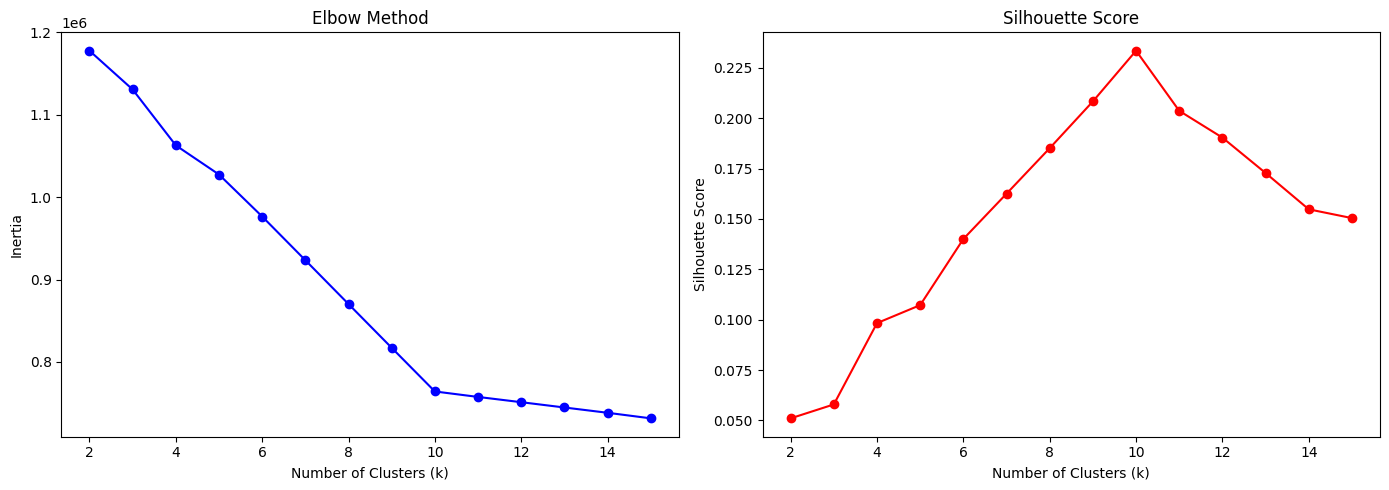

In [ ]:
inertias = []
silhouette_scores = []
k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_, sample_size=5000, random_state=42))
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

# Plot both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.show()

## Section 3: Initial K-Means Exploration

In [ ]:
# Train final K-Means model with k=10
kmeans_final = KMeans(n_clusters=10, random_state=42, n_init=10)
df_model['Cluster'] = kmeans_final.fit_predict(df_scaled)

# See how many games landed in each cluster
print("Games per cluster:")
print(df_model['Cluster'].value_counts().sort_index())
print()

# Inspect cluster profiles using original-scale features
profile_cols = ['User Rating', 'Price', 'Game Length (Hours)', 'Graphics Quality',
                'Soundtrack Quality', 'Story Quality', 'Release Year']
print("Cluster averages:")
df_model.groupby('Cluster')[profile_cols].mean().round(2)

Games per cluster:
Cluster
0    4867
1    4735
2    4869
3    4784
4    4822
5    4873
6    4750
7    4639
8    4687
9    4748
Name: count, dtype: int64

Cluster averages:


,User Rating,Price,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,Release Year
Cluster,,,,,,,
0,29.72,39.95,32.51,1.50,1.53,1.52,2016.40
1,29.70,39.77,32.69,1.50,1.49,1.49,2016.52
2,29.63,40.04,32.06,1.49,1.50,1.49,2016.42
3,29.65,40.11,32.03,1.54,1.50,1.50,2016.45
4,29.76,39.97,32.58,1.50,1.51,1.50,2016.51
5,29.77,39.83,32.72,1.48,1.51,1.50,2016.31
6,29.70,39.76,32.74,1.50,1.53,1.52,2016.56
7,29.69,39.99,32.32,1.50,1.51,1.51,2016.54
8,29.79,39.77,33.02,1.49,1.48,1.48,2016.58


In [ ]:
# Check genre and platform distribution per cluster
genre_cols = [col for col in df_model.columns if col.startswith('Genre_')]
platform_cols = [col for col in df_model.columns if col.startswith('Platform_')]

print("=== Dominant Genre per Cluster ===")
genre_profile = df_model.groupby('Cluster')[genre_cols].mean().round(3)
for cluster in range(10):
    top_genre = genre_profile.loc[cluster].idxmax().replace('Genre_', '')
    top_val = genre_profile.loc[cluster].max()
    print(f"Cluster {cluster}: {top_genre} ({top_val:.1%})")

print()
print("=== Dominant Platform per Cluster ===")
platform_profile = df_model.groupby('Cluster')[platform_cols].mean().round(3)
for cluster in range(10):
    top_platform = platform_profile.loc[cluster].idxmax().replace('Platform_', '')
    top_val = platform_profile.loc[cluster].max()
    print(f"Cluster {cluster}: {top_platform} ({top_val:.1%})")

=== Dominant Genre per Cluster ===
Cluster 0: Strategy (100.0%)
Cluster 1: Sports (100.0%)
Cluster 2: Shooter (100.0%)
Cluster 3: Simulation (100.0%)
Cluster 4: Puzzle (100.0%)
Cluster 5: RPG (100.0%)
Cluster 6: Adventure (100.0%)
Cluster 7: Action (100.0%)
Cluster 8: Fighting (100.0%)
Cluster 9: Party (100.0%)

=== Dominant Platform per Cluster ===
Cluster 0: PC (20.6%)
Cluster 1: Mobile (20.4%)
Cluster 2: Nintendo Switch (20.5%)
Cluster 3: Nintendo Switch (20.6%)
Cluster 4: Mobile (20.4%)
Cluster 5: PC (20.3%)
Cluster 6: Mobile (20.6%)
Cluster 7: Mobile (20.3%)
Cluster 8: PlayStation (20.6%)
Cluster 9: PlayStation (22.0%)


In [ ]:
# Remove genre columns and re-scale
genre_cols = [col for col in df_features.columns if col.startswith('Genre_')]
df_features_no_genre = df_features.drop(columns=genre_cols)

scaler2 = StandardScaler()
df_scaled_no_genre = pd.DataFrame(scaler2.fit_transform(df_features_no_genre),
                                   columns=df_features_no_genre.columns)

# Re-run silhouette test for a few k values
for k in [5, 8, 10, 12]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled_no_genre)
    score = silhouette_score(df_scaled_no_genre, labels, sample_size=5000, random_state=42)
    print(f"k={k}: Silhouette={score:.4f}")

k=5: Silhouette=0.2078
k=8: Silhouette=0.1374
k=10: Silhouette=0.1146
k=12: Silhouette=0.1048


In [ ]:
# Train with k=5 on non-genre features
kmeans_no_genre = KMeans(n_clusters=5, random_state=42, n_init=10)
df_model['Cluster_v2'] = kmeans_no_genre.fit_predict(df_scaled_no_genre)

# Check cluster sizes
print("Games per cluster:")
print(df_model['Cluster_v2'].value_counts().sort_index())
print()

# Check numeric profiles
profile_cols = ['User Rating', 'Price', 'Game Length (Hours)', 'Graphics Quality',
                'Soundtrack Quality', 'Story Quality', 'Release Year', 'Min Number of Players']
print("Cluster averages:")
print(df_model.groupby('Cluster_v2')[profile_cols].mean().round(2))
print()

# Check platform distribution
print("=== Platform Distribution per Cluster ===")
platform_cols = [col for col in df_model.columns if col.startswith('Platform_')]
print(df_model.groupby('Cluster_v2')[platform_cols].mean().round(3))
print()

# Check categorical features
print("=== Other Features per Cluster ===")
cat_cols = ['Age Group Targeted', 'Multiplayer', 'Game Mode']
print(df_model.groupby('Cluster_v2')[cat_cols].mean().round(2))

Games per cluster:
Cluster_v2
0    9357
1    9589
2    9633
3    9596
4    9599
Name: count, dtype: int64

Cluster averages:
            User Rating  Price  Game Length (Hours)  Graphics Quality  \
Cluster_v2                                                              
0                 29.65  39.86                32.43              1.51   
1                 29.86  40.03                32.82              1.50   
2                 29.76  40.03                32.52              1.50   
3                 29.64  39.83                32.40              1.50   
4                 29.69  40.01                32.24              1.49   

            Soundtrack Quality  Story Quality  Release Year  \
Cluster_v2                                                    
0                         1.51           1.50       2016.50   
1                         1.51           1.50       2016.48   
2                         1.50           1.49       2016.49   
3                         1.51           1.50   

## Section 4: Model Experimentation & Comparison

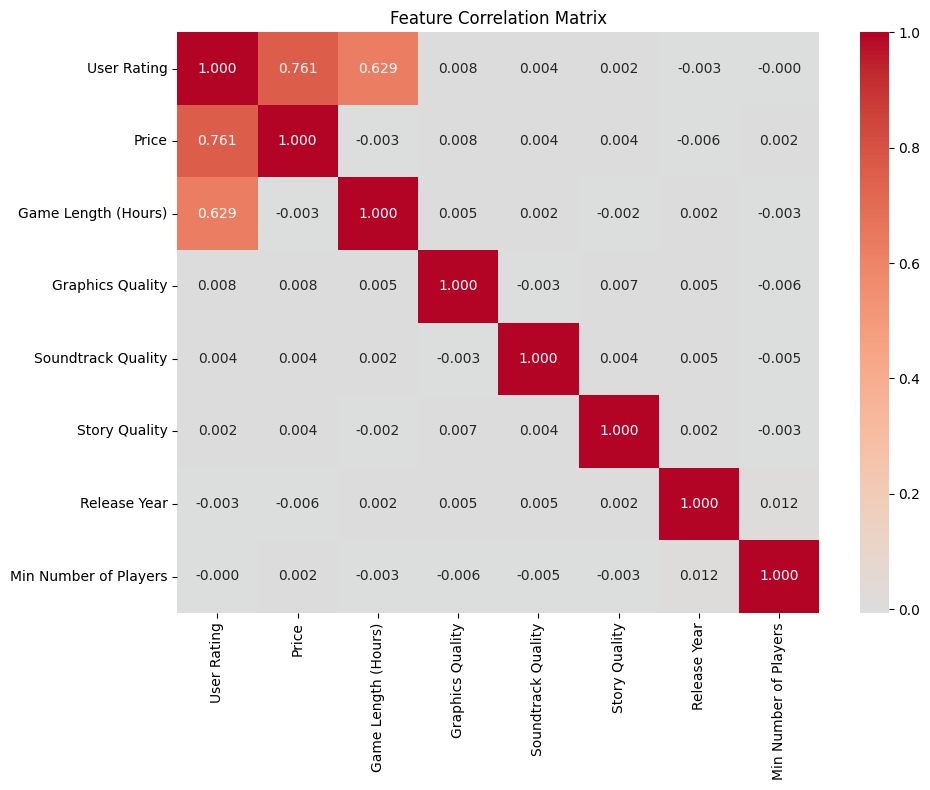

Standard deviations:
User Rating               7.55
Price                    11.52
Game Length (Hours)      15.87
Graphics Quality          1.11
Soundtrack Quality        1.12
Story Quality             1.12
Release Year              4.03
Min Number of Players     2.77
dtype: float64

Value ranges:
     User Rating  Price  Game Length (Hours)  Graphics Quality  \
min         10.1  19.99                  5.0               0.0   
max         49.5  59.99                 60.0               3.0   

     Soundtrack Quality  Story Quality  Release Year  Min Number of Players  
min                 0.0            0.0        2010.0                    1.0  
max                 3.0            3.0        2023.0                   10.0  


In [ ]:
# Check if numeric features have any correlation with each other
numeric_cols = ['User Rating', 'Price', 'Game Length (Hours)', 'Graphics Quality',
                'Soundtrack Quality', 'Story Quality', 'Release Year', 'Min Number of Players']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_model[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.3f', ax=ax)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Also check the distributions
print("Standard deviations:")
print(df_model[numeric_cols].std().round(2))
print()
print("Value ranges:")
print(df_model[numeric_cols].describe().loc[['min', 'max']])